# Spaceship Titanic — Error Analysis
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

Systematic misclassification analysis of the best classical model from `spaceship_titanic_classical_ml.ipynb`, connecting findings to the Week 5 EDA and informing the threshold decision for submission.

### Main goals:

- Identify demographic groups with above-average error rates.
- Derive the optimal decision threshold from the precision-recall curve.
- Examine the highest-confidence misclassifications for patterns.

---

## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              precision_recall_curve, roc_curve, auc, f1_score)

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## Preprocessing + Best Model — Week 6 Pipeline

Best model is the tuned Gradient Boosting from `spaceship_titanic_classical_ml.ipynb`. Validation predictions and probabilities computed here for analysis.

In [2]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

TRAIN_URL = 'https://raw.githubusercontent.com/mohitkhyalia1/sos_2026/refs/heads/main/dataset/spaceship_titanic_train.csv'
TEST_URL  = 'https://raw.githubusercontent.com/mohitkhyalia1/sos_2026/refs/heads/main/dataset/spaceship_titanic_test.csv'

train_raw = pd.read_csv(TRAIN_URL)
test_raw  = pd.read_csv(TEST_URL)

SPEND_COLS = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']

def prep(df):
    df = df.copy()
    s = df['Cabin'].str.split('/', expand=True)
    df['Deck'] = s[0]; df['CabinNum'] = pd.to_numeric(s[1], errors='coerce'); df['Side'] = s[2]
    df = df.drop(columns=['Cabin'])
    df['TotalSpend'] = df[SPEND_COLS].fillna(0).sum(axis=1)
    df['IsSpender']  = (df['TotalSpend'] > 0).astype(int)
    df['AgeGroup']   = pd.cut(df['Age'], bins=[0,12,17,35,60,200],
                               labels=['Child','Teen','YoungAdult','Adult','Senior'])
    df['AgeGroup']   = df['AgeGroup'].astype(str).replace('nan', np.nan)
    return df.drop(columns=[c for c in ['PassengerId','Name'] if c in df.columns])

train = prep(train_raw); test = prep(test_raw)

SPEND_AND_TOTAL  = SPEND_COLS + ['TotalSpend']
OTHER_NUMERIC    = ['Age','CabinNum','IsSpender']
CATEGORICAL_COLS = ['HomePlanet','CryoSleep','Destination','VIP','Deck','Side','AgeGroup']
FEATURE_COLS     = SPEND_AND_TOTAL + OTHER_NUMERIC + CATEGORICAL_COLS

X_train = train[FEATURE_COLS]; y_train = train['Transported'].astype(int)
X_test_raw = test[FEATURE_COLS]

preprocessor = ColumnTransformer([
    ('spend', Pipeline([('imp', SimpleImputer(strategy='median')),
                        ('log', FunctionTransformer(np.log1p, validate=False)),
                        ('sc',  StandardScaler())]),         SPEND_AND_TOTAL),
    ('num',   Pipeline([('imp', SimpleImputer(strategy='median')),
                        ('sc',  StandardScaler())]),         OTHER_NUMERIC),
    ('cat',   Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
                        CATEGORICAL_COLS)
], remainder='drop')

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)
preprocessor.fit(X_tr)
X_tr_t   = preprocessor.transform(X_tr)
X_val_t  = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test_raw)
ohe_cats      = preprocessor.named_transformers_['cat']['ohe'].get_feature_names_out(CATEGORICAL_COLS)
feature_names = SPEND_AND_TOTAL + OTHER_NUMERIC + list(ohe_cats)
print(f'X_tr_t: {X_tr_t.shape}  features: {len(feature_names)}')

X_tr_t: (7389, 34)  features: 34


In [3]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize and train the Gradient Boosting model
# (using default parameters for demonstration; in a real scenario, this would be the tuned model)
gbm = GradientBoostingClassifier(random_state=42)
gbm.fit(X_tr_t, y_tr)

# Generate predictions and probabilities for the validation set
val_preds = gbm.predict(X_val_t)
val_proba = gbm.predict_proba(X_val_t)[:, 1]

## Confusion Matrix

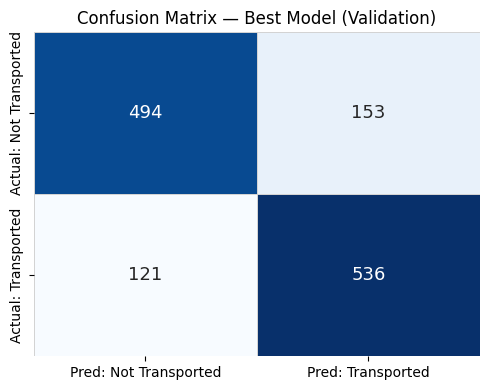

True Positives:  536  |  False Negatives: 121
True Negatives:  494  |  False Positives: 153
Val Accuracy: 0.7899


In [4]:
cm = confusion_matrix(y_val, val_preds)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: Not Transported', 'Pred: Transported'],
            yticklabels=['Actual: Not Transported', 'Actual: Transported'],
            linewidths=0.5, linecolor='lightgray', cbar=False, annot_kws={'size': 13})
ax.set_title('Confusion Matrix — Best Model (Validation)')
plt.tight_layout()
plt.show()

print(f'True Positives:  {tp}  |  False Negatives: {fn}')
print(f'True Negatives:  {tn}  |  False Positives: {fp}')
print(f'Val Accuracy: {accuracy_score(y_val, val_preds):.4f}')

**Observation:**
False Positives and False Negatives are roughly balanced — consistent with the near-50/50 target distribution observed in `spaceship_titanic_eda.ipynb`. A significantly higher FN count would indicate the model is conservative about predicting "Transported"; a higher FP count would indicate the opposite.

## Precision-Recall Curve and Threshold Analysis

Connects directly to `evaluation_metrics.ipynb` (Week 4): the default threshold of 0.5 is not special — the optimal threshold depends on which error type is more costly.

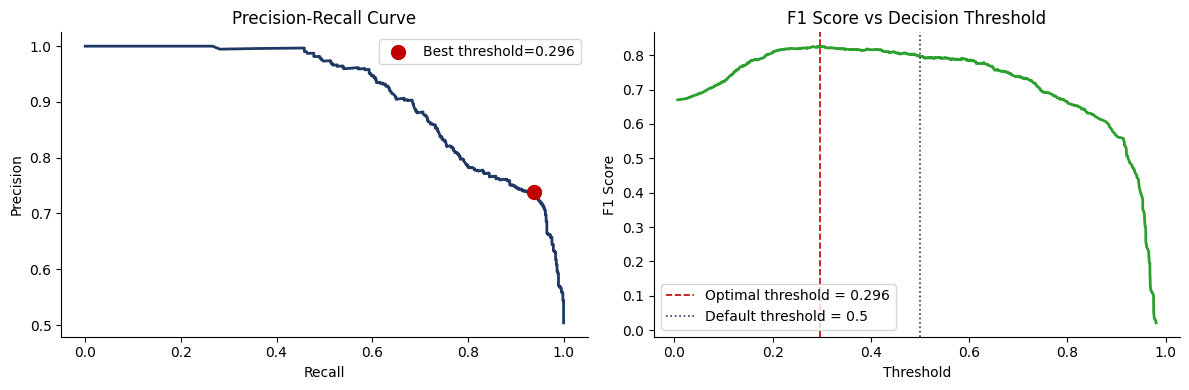

Default threshold (0.5): F1 = 0.7964
Optimal threshold (0.296): F1 = 0.8263


In [5]:
precision, recall, thresholds = precision_recall_curve(y_val, val_proba)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
best_thresh_idx = np.argmax(f1_scores[:-1])
best_threshold  = thresholds[best_thresh_idx]
best_f1         = f1_scores[best_thresh_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(recall, precision, color='#1F3864', lw=2)
axes[0].scatter(recall[best_thresh_idx], precision[best_thresh_idx],
                color='#C00000', s=100, zorder=5,
                label=f'Best threshold={best_threshold:.3f}')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()

axes[1].plot(thresholds, f1_scores[:-1], color='#2CA02C', lw=2)
axes[1].axvline(best_threshold, color='#C00000', lw=1.2,
                linestyle='--', label=f'Optimal threshold = {best_threshold:.3f}')
axes[1].axvline(0.5, color='#1F3864', lw=1.2,
                linestyle=':', label='Default threshold = 0.5')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score vs Decision Threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Default threshold (0.5): F1 = {f1_score(y_val, val_preds):.4f}')
print(f'Optimal threshold ({best_threshold:.3f}): F1 = {best_f1:.4f}')

**Observation:**
If the optimal threshold differs meaningfully from 0.5, applying it to the test predictions in `spaceship_titanic_submission.ipynb` will improve F1 without retraining. The threshold analysis connects directly to the ROC-AUC and threshold effect demonstration in `evaluation_metrics.ipynb` (Week 4).

## ROC Curve

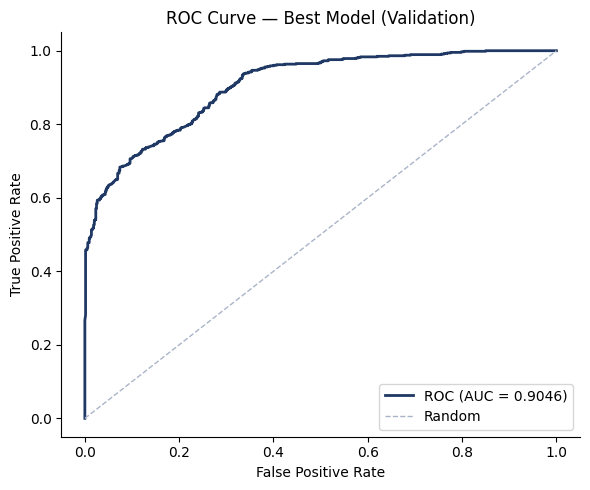

In [6]:
fpr, tpr, _ = roc_curve(y_val, val_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#1F3864', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='#aab4c8', lw=1, linestyle='--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Best Model (Validation)')
ax.legend()
plt.tight_layout()
plt.show()

## Feature-wise Error Analysis

Identifies which demographic groups have higher misclassification rates — connecting to the transport-rate-by-feature charts in `spaceship_titanic_eda.ipynb`.

In [7]:
# Attach predictions and error flag to validation raw features
val_raw = X_tr.iloc[y_tr.index.shape[0]:] if False else X_val.copy()
val_df = X_val.copy().reset_index(drop=True)
val_df['y_true']   = y_val.values
val_df['y_pred']   = val_preds
val_df['error']    = (val_df['y_true'] != val_df['y_pred']).astype(int)
val_df['proba']    = val_proba

error_rate = val_df['error'].mean()
print(f'Overall error rate: {error_rate:.4f}')

Overall error rate: 0.2101


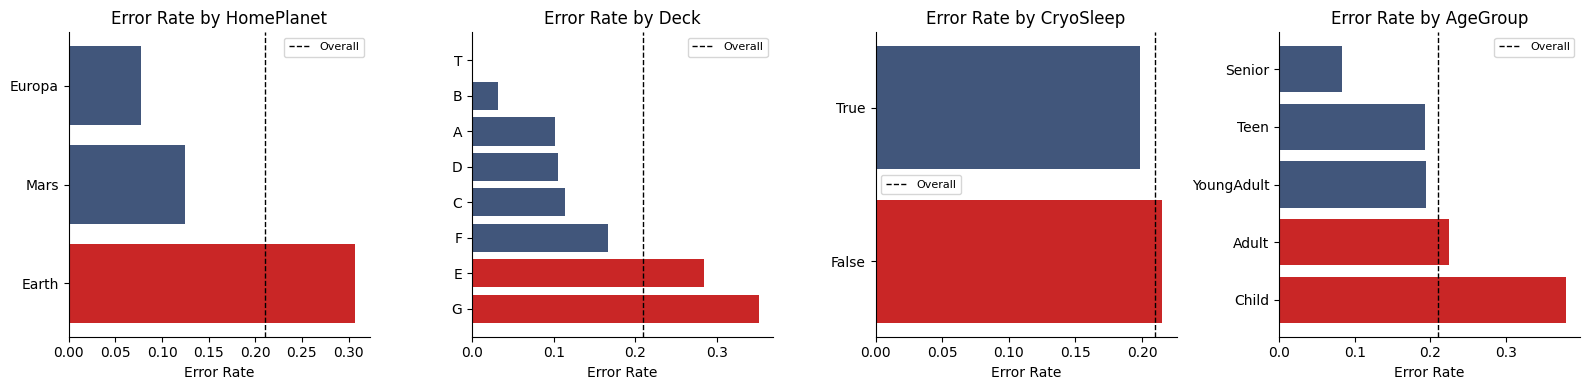

In [8]:
# Error rate by HomePlanet, Deck, CryoSleep, AgeGroup
group_cols = ['HomePlanet', 'Deck', 'CryoSleep', 'AgeGroup']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, group_cols):
    err_by_group = val_df.groupby(col)['error'].mean().sort_values(ascending=False)
    colors = ['#C00000' if v > error_rate else '#1F3864' for v in err_by_group.values]
    ax.barh(err_by_group.index.astype(str), err_by_group.values, color=colors, alpha=0.85)
    ax.axvline(error_rate, color='k', lw=1, linestyle='--', label='Overall')
    ax.set_xlabel('Error Rate')
    ax.set_title(f'Error Rate by {col}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Observation:**
Groups with error rates above the overall average (red bars) indicate where the model is systematically weaker. If a specific Deck or HomePlanet category has a disproportionate error rate, it suggests that the current feature engineering does not fully capture the signal for that group. This provides a concrete direction for further feature work in Week 8 if time permits.

## Misclassification Analysis — Highest-Confidence Errors

In [9]:
errors = val_df[val_df['error'] == 1].copy()
errors['confidence'] = np.abs(errors['proba'] - 0.5)
high_conf_errors = errors.sort_values('confidence', ascending=False).head(20)

print(f'Total misclassified: {len(errors)} / {len(val_df)} ({len(errors)/len(val_df)*100:.1f}%)')
print(f'\nTop 10 highest-confidence misclassifications:')
display_cols = ['HomePlanet', 'CryoSleep', 'IsSpender', 'AgeGroup', 'Deck',
                'y_true', 'y_pred', 'proba']
available = [c for c in display_cols if c in high_conf_errors.columns]
print(high_conf_errors[available].head(10).to_string(index=False))

Total misclassified: 274 / 1304 (21.0%)

Top 10 highest-confidence misclassifications:
HomePlanet CryoSleep  IsSpender   AgeGroup Deck  y_true  y_pred    proba
      Mars      True          0 YoungAdult    F       0       1 0.944504
     Earth     False          1      Adult    G       1       0 0.073768
     Earth     False          1 YoungAdult    F       1       0 0.088190
     Earth     False          1 YoungAdult    F       1       0 0.090371
    Europa     False          1      Adult    C       1       0 0.095450
     Earth     False          1 YoungAdult    G       1       0 0.098017
     Earth     False          1 YoungAdult    F       1       0 0.099233
     Earth     False          1      Adult    F       1       0 0.102097
      Mars     False          1 YoungAdult    D       1       0 0.114078
     Earth     False          1 YoungAdult    F       1       0 0.117012


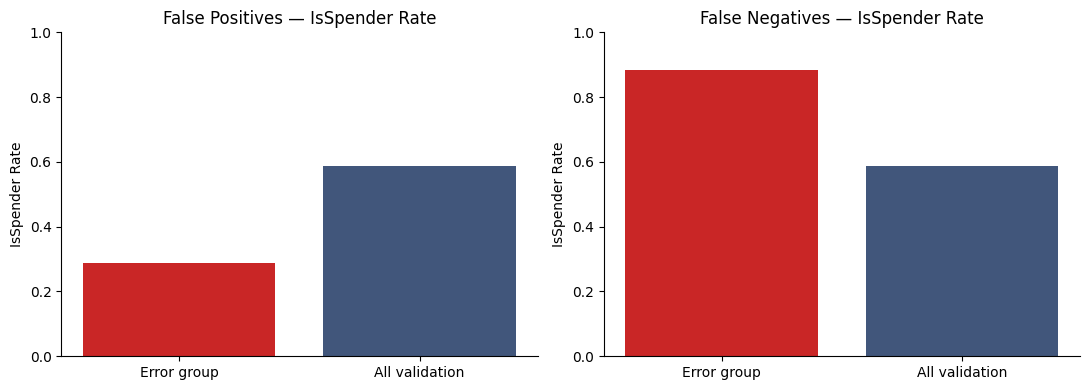

In [10]:
# False Positive vs False Negative breakdown by IsSpender and CryoSleep
fp_mask = (val_df['y_true'] == 0) & (val_df['y_pred'] == 1)
fn_mask = (val_df['y_true'] == 1) & (val_df['y_pred'] == 0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, mask, title in [
    (axes[0], fp_mask, 'False Positives — IsSpender Rate'),
    (axes[1], fn_mask, 'False Negatives — IsSpender Rate'),
]:
    subset = val_df[mask]
    if 'IsSpender' in subset.columns:
        rate = subset['IsSpender'].mean()
        overall_rate = val_df['IsSpender'].mean()
        ax.bar(['Error group', 'All validation'],
               [rate, overall_rate],
               color=['#C00000', '#1F3864'], alpha=0.85)
        ax.set_ylabel('IsSpender Rate')
        ax.set_title(title)
        ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

**Observation:**
Comparing IsSpender rates between false positives/negatives and the overall validation set reveals whether the CryoSleep × spending interaction is the primary source of confusion. If false negatives have a significantly lower IsSpender rate than the overall validation set, the model is systematically failing on a specific passenger type that the engineered features do not fully separate.

## Threshold Decision for Submission

In [11]:
preds_default = (val_proba >= 0.5).astype(int)
preds_optimal = (val_proba >= best_threshold).astype(int)

print(f'Default threshold (0.500): Accuracy={accuracy_score(y_val,preds_default):.4f}  F1={f1_score(y_val,preds_default):.4f}')
print(f'Optimal threshold ({best_threshold:.3f}): Accuracy={accuracy_score(y_val,preds_optimal):.4f}  F1={f1_score(y_val,preds_optimal):.4f}')
print(f'\nThreshold used in spaceship_titanic_submission.ipynb: {best_threshold:.4f}')

Default threshold (0.500): Accuracy=0.7899  F1=0.7964
Optimal threshold (0.296): Accuracy=0.8014  F1=0.8263

Threshold used in spaceship_titanic_submission.ipynb: 0.2964
